<div style="font-size:18px">

**Download this Notebook**

</div>

Click [here](https://github.com/serc-chile/SERCpy/releases/download/meteo_profile_tutorial/MeteoProfile_tutorial.zip) to download this ipynb file and run it locally in your machine.

The notebook comes as part of a zip file along with a csv file that is used to import de ambient temperature data.

<div style="height:20px;"></div>

# MeteoProfile class tutorial

`MeteoProfile` instances are meant to process, store and provide the meteorological conditions to which an eventual solar heating system would be subject throughout an entire operation year. Some of their features are:

- They are meant to use meteorological data of type TMY (typical meteorological year), which is a dataset that encompasses a whole year (usually with hourly resolution, although the platform accepts files with up to 1-minute resolution), and seeks to be representative of the irradiance conditions in the place where the solar energy system will be located.
- If no information is provided by the user, the class is able to automatically establish the time zone based on the location to which the meteorological data corresponds; this includes the eventual use of daylight saving time.
- They are capable of computing the POA* irradiance on solar fields, as well as the incidence angle modifier (IAM) factor.
- They are capable of modeling self-shading phenomena affecting solar fields, both for direct and for diffuse components of incident irradiance.
- For locations within the Chilean territory, they are able to automatically download the data from the [Renewable Energy API by Chilean Ministry of Energy](https://api.minenergia.cl).

*Plane of Array

In [1]:
# Import DemandProfile and other modules needed
# If the two last code lines are activated, the plots will be rendered in separate windows

from sercpy.meteo_profile import MeteoProfile
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'qt')

## 1. Establishing the TMY data

### 1.1. Providing the TMY data file

#### Solar Explorer files

If the user is going to simulate solar heating systems within the Chilean territory, a viable option is to obtain TMY files from [Chilean Ministry of Energy's "Solar Energy Explorer"](https://solar.minenergia.cl/inicio), as shown in image below.

After accessing [this link](https://solar.minenergia.cl/exploracion), the user must select a location within the Chilean territory. After doing this, a panel will appear at the left side of the screen. The steps to download the TMY file are illustrated in the image below:

1. Select the tab **"DESCARGAS"** in the panel at the left.  
2. Download the file by selecting the option **"Datos Horarios TMY"**.

<br>

<div style="text-align: center;">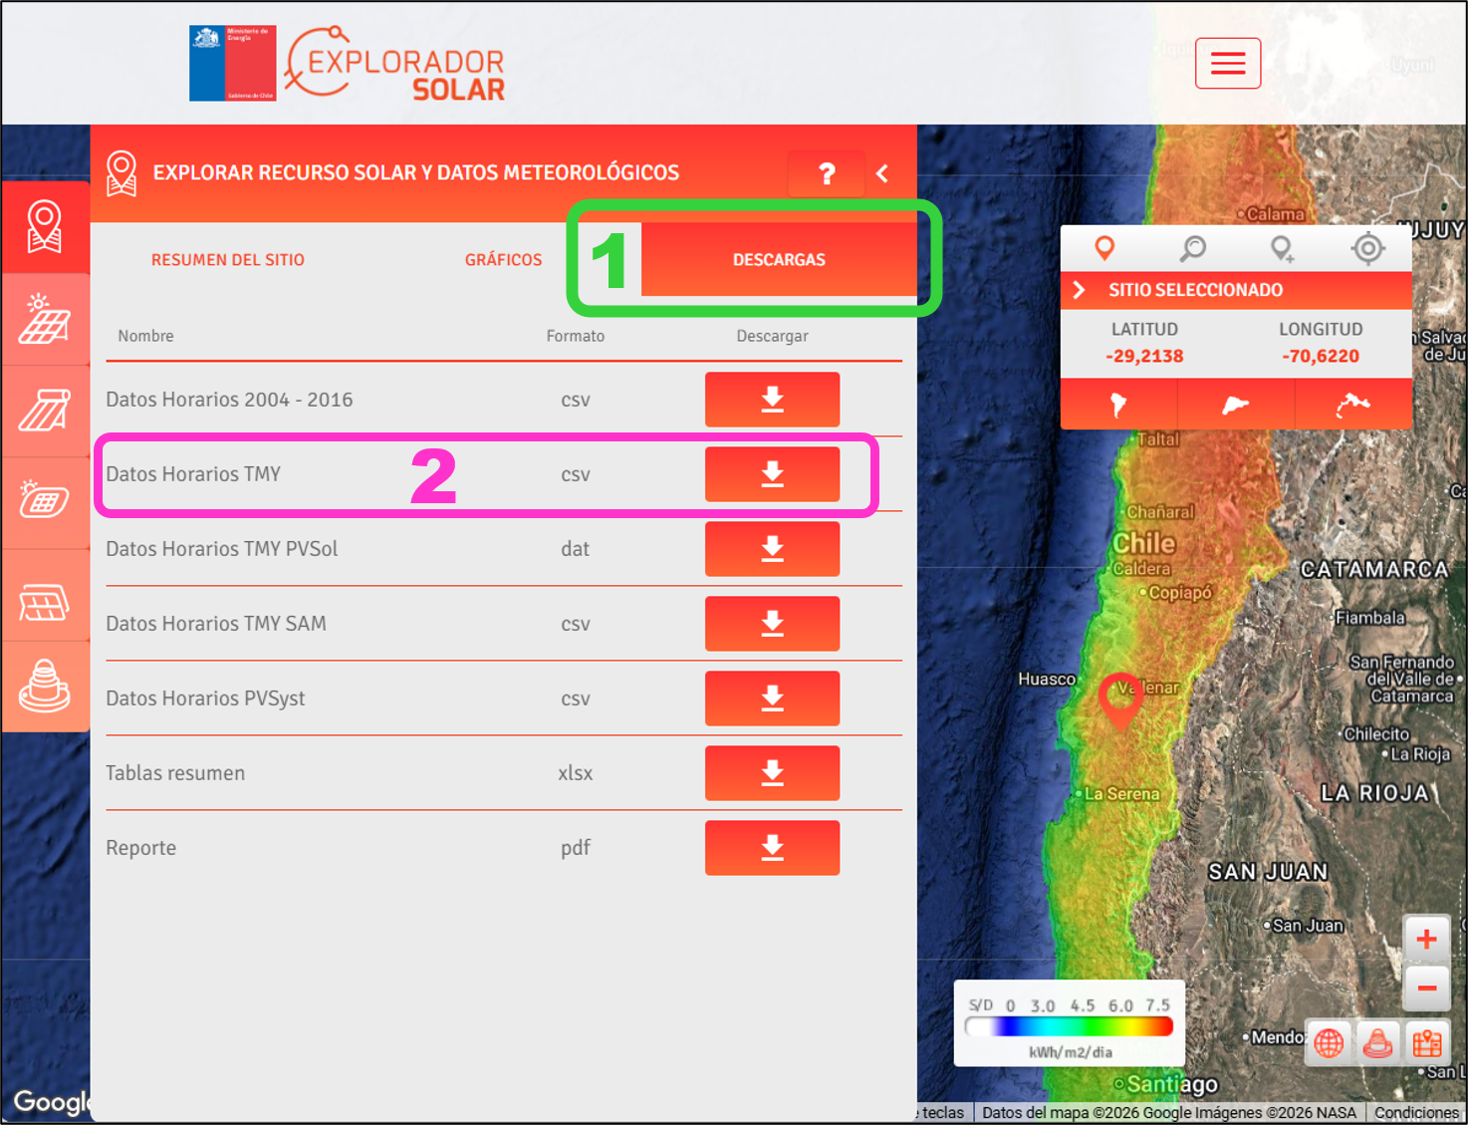</div>
<div style="text-align: center; font-weight: bold;">Illustration of how to download TMY files from Ministry of Energy's "Solar Energy Explorer"</div>

After downloading the TMY file, a `MeteoProfile` instance can be generated merely by providing the path of the file through the argument `tmy_file_path` (or simply the name of the file, provided that the data file and the code that is being run are in the same folder).

The `MeteoProfile` class automatically identifies the file's format and extracts not only the meteorological data, but also the location and the elevation, which is used to compute the atmospheric pressure at the corresponding location.

In [2]:
meteo_conditions = MeteoProfile( tmy_file_path = "TMY_Solar_Explorer.csv" )

#### SAM-formatted files

The class `MeteoProfile` is also able to process files that are formatted according to the [SAM (System Advisor Model)](https://sam.nlr.gov/) standard.

This is a useful option for users that want to use the library to carry out simulations outside of the Chilean territory, since this format is produced by platforms that deliver meteorological data in other zones of the world.

The ["Solar Explorer" website](https://solar.minenergia.cl/inicio) has the option of producing this kind of files as well, as shown in the image above.

In [3]:
meteo_conditions = MeteoProfile( tmy_file_path = "TMY_SAM.csv" )

#### Custom files

It is also possible to extract data from csv files that do not follow either of the formats just mentioned. Some aspects to keep in mind in this case are as follows:

- The location must be provided through the initialization arguments of the `DemandProfile` instance. It can be provided either through the argument `location` as a `tuple` with the form `(latitude, longitude)`, or through the separate arguments `latitude` and `longitude`.
  
- It is strongly recommended to provide the UTC offset of the data (in hours) through the argument `tmy_utc_offset`. If not provided, the UTC offset is inferred from the location provided by the user. This can lead to large errors were this assumption wrong. For zones that observe daylight saving time (i.e. summer time), the UTC offset for winter is assumed. E.g. in the Eastern Coast of the United States, this value would be -5. In Chile, it would be -4.

- The elevation can be provided by the user through the argument `elevation`, and the units through the argument `elevation_units`. If the latter argument is not provided, the former is assumed to be expressed in meters. If neither of the parameters is provided, the standard atmospheric pressure at sea level is assumed (i.e. 101,325 Pa).

- The data must have at least hourly resolution, and higher resolutions are accepted as well. It is always assumed that the data consists of a whole meteorological year, and that the samples are evenly spaced in time.

- The data must have a column representing ambient temperature, and at least two of the three columns for irradiance components: GHI, DNI, and DHI. The name of each of these columns can be customized through the arguments `Tamb_col_name`, `ghi_col_name`, `dni_col_name`, and `dhi_col_name`. If these arguments are not provided, the names of those columns in the data file should be `"Tamb"`, `"GHI"`, `"DNI"`, and `"DHI"`, respectively.

- It is assumed that the first data sample corresponds to the average variable values during the first hour of the year, for files with hourly resolution. For higher resolutions, the same applies for the corresponding (shorter) time span.

- The arguments `sep`, `delimiter`, and `skiprows` can be used to customize the csv reading just as in the function [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [4]:
meteo_conditions = MeteoProfile( 
    
    tmy_file_path = "TMY_custom.csv",
    latitude = -33.49818458807115,
    longitude = -70.60757631044005,
    tmy_utc_offset = -4,
    elevation = 579,
    Tamb_col_name = "ambient_temp",
    ghi_col_name = "global_horizontal",
    dni_col_name = "direct_normal",
    dhi_col_name = "diffuse_horizontal",
    sep = ";",
    skiprows = 3,
    
    )

### 1.2. Downloading files from "Renewable Energies API"

If the user is going to carry out simulations within the Chilean territory and owns an API key for [Chilean Ministry of Energy's "Renewable Enrergies API"](https://solar.minenergia.cl/inicio), it is possible to skip the step of downloading a TMY data file manually.

For this initialization mode to work, the location provided must be within the Chilean territory.

#### Providing the key when initializing the class

When the `DemandProfile` instance is initialized, it is possible for the user to provide only the location (either as a `tuple` or as two separate arguments), and their API key through the argument `api_key`. The class automatically calls the API to obtain the meteorological data needed.

In [ ]:
meteo_conditions = MeteoProfile( 
    
    location = (-33.49818458807115, -70.60757631044005),
    
    api_key  = "",
    #          ^^
    # API key here
    
    )

#### Saving the API key for future simulations

Another option that will simplify future simulations is to store the API key within the configuration of the library. This allows the user not to provide their API key every time a simulation is initialized.

This is done by calling the function `set_api_key` from the module `config`.

In [ ]:
from sercpy.config import set_api_key

set_api_key( "" )
#            ^^
#   API key here

After doing this, a `MeteoProfile` instance can be initialized by merely providing a location.

In [ ]:
meteo_conditions = MeteoProfile( 
    
    location = (-33.49818458807115, -70.60757631044005)
    
    )

If the user ever needs to retrieve an already stored API key for purposes other than initializing a `MeteoProfile` instance, it is possible to get it with the function `config.get_api_key`. Thus, storing the key may also reduce the risk of not being able to access it when needed.

In [ ]:
from sercpy.config import get_api_key

print( get_api_key() )

## 2. Computing the irradiance conditions for a specific solar field

Having irradiance data for a certain location (more precisely, the components GHI, DNI, and DHI) is not enough to simulate a solar energy system there. The following results also need to be computed:

- Irradiance on the plane of the collector/panel array.
- Incidence angle modifier (IAM) factor for every instant of the simulated year.
- Eventual self-shading of the solar collector field

Although these results could theoretically be computed during the system simulation, it is way faster to compute them in advance before the simulation begins. This does not impact the accuracy of the simulation since the results computed do not depend on any condition that is not known beforehand.

There are two possible ways of computing the irradiance conditions on a solar field:

- Providing an instance of the class `solar_field.SolarField` when the `MeteoProfile` instance is being initialized. This is done with the argument `solar_field`.
  
- Calling the method `meteo_profile.compute_poa_irradiance( solar_field )`, where `meteo_profile` is an instance of `MeteoProfile` previously defined, and `solar_field` is an instance of the class `solar_field.SolarField`.

In [5]:
# The function solar_field.example_solar_field returns a generic SolarField instance that can be used to get familiarized with the library
from sercpy.solar_field import example_solar_field

latitude = -33.49818458807115
longitude = -70.60757631044005
field_gross_area = 200

solar_field = example_solar_field(
    
    latitude = latitude,
    longitude = longitude,
    field_gross_area = field_gross_area,
    
    )

In [6]:
# If the object solar_field is provided to the class MeteoProfile when initialized, the aforementioned results are computed automatically.

meteo_conditions = MeteoProfile(
    
    tmy_file_path = "TMY_Solar_Explorer.csv",
    solar_field = solar_field,

    )

In [7]:
# The irradiance conditions for a certain solar field can be computed for an already-defined MeteoProfile instance
# using the method MeteoProfile.compute_poa_irradiance

meteo_conditions = MeteoProfile( tmy_file_path = "TMY_Solar_Explorer.csv" )

meteo_conditions.compute_poa_irradiance( solar_field )

## 3. Retrieving data from MeteoProfile instances

The method that allows the user to extract results from a `MeteoProfile` instance is called `MeteoProfile.get_conditions()`. Calling this method without any extra arguments, besides the `MeteoProfile` instance, yields the whole dataset stored by that object. This dataset consists of a `pandas.DataFrame`, with minutal resolution, where the data starts on January 1st at 00:00, and ends at December 31st at 23:59.

The columns of the `DataFrame` are:

- `"timestamp"`: Column of `pandas.Timestamp` instances defining the moment each sample corresponds to.
- `"GHI"`: Global horizontal irradiance
- `"DNI"`: Direct normal irradiance
- `"DHI"`: Diffuse horizontal irradiance
- `"azimuth"`: Azimuthal angle of the solar position. North corresponds to zero, and the value increases towards east (i.e., clockwise).
- `"zenith"`: Zenithal angle of the solar position.
- `"apparent_zenith"`: Apparent zenithal angle of the solar position. See [get_solarposition by pvlib](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.solarposition.get_solarposition.html).
- `"Tamb"`: Ambient temperature.
- `"Tmains"`: Mains water temperature, computed with the algorithm described in the [study by Burch and Christensen](https://www.osti.gov/biblio/981988).

Only if a `solar_field.SolarField` has been used to compute the results relative to that solar field, as discussed above, the following columns are also included in the `DataFrame`:

- `"aoi"`: Angle of incidence on the solar field array. The value is `None` for values outside of the sky dome visible from the plane of the array (i.e., values larger than 90°).
- `"aoi_l"`: Angle of incidence in the transversal plane. The value is `None` for values outside of the sky dome visible from the plane of the array (i.e., values larger than 90°).
- `"aoi_t"`: Angle of incidence in the longitudinal plane. The value is `None` for values outside of the sky dome visible from the plane of the array (i.e., values larger than 90°).
- `"irradiance_first_row"`: Irradiance inciding on the first row of collectors/panels (not subject to self-shading).
- `"irradiance_shadeable_rows"`: Irradiance inciding on the collector rows that are subject to self-shading.
- `"IAM_first_row"`: Incidence angle modifier factor for the first collector row (not subject to self-shading).
- `"IAM_shadeable_rows"`: Incidence angle modifier factor for the collector rows that are subject to self-shading.

In [8]:
conditions = meteo_conditions.get_conditions()

print( f"Type of result: { type( conditions ) }" )
print("")
print(f"Columns of the DataFrame: { conditions.columns.tolist() }")
print("")
print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Type of result: <class 'pandas.core.frame.DataFrame'>

Columns of the DataFrame: ['timestamp', 'GHI', 'DNI', 'DHI', 'Tamb', 'azimuth', 'zenith', 'apparent_zenith', 'Tmains', 'aoi', 'aoi_l', 'aoi_t', 'irradiance_first_row', 'irradiance_shadeable_rows', 'IAM_first_row', 'IAM_shadeable_rows']

Length of the DataFrame: 525600

First instant: 2025-01-01 00:00:00-03:00

Last instant: 2025-12-31 23:59:00-03:00


### 3.1. Retrieving a whole month, day, or hour

If the keyword argument `month` is specified to the method `MeteoProfile.get_conditions()`, with allowed values `1` to `12`, only the data corresponding to that month will be returned.

In [9]:
# Retrieving only the data corresponding to May
conditions = meteo_conditions.get_conditions(month = 5)

print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Length of the DataFrame: 44640

First instant: 2025-05-01 00:00:00-04:00

Last instant: 2025-05-31 23:59:00-04:00


If the argument `day` is provided along with the argument `month` (with allowed values `1` to the number of days of the corresponding month), only the data of that date is returned. 

In [10]:
# Retrieving only the data corresponding to February 12th
conditions = meteo_conditions.get_conditions(month = 2, day = 12)

print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Length of the DataFrame: 1440

First instant: 2025-02-12 00:00:00-03:00

Last instant: 2025-02-12 23:59:00-03:00


If the argument `hour` is provided along with the arguments `month` and `day` (with allowed values `0` to `23`), only the data of that hour is returned. 

In [11]:
# Retrieving only the data corresponding to October 5th, from 11:00 to 11:59
conditions = meteo_conditions.get_conditions(month = 10, day = 5, hour = 11 )

print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Length of the DataFrame: 60

First instant: 2025-10-05 11:00:00-03:00

Last instant: 2025-10-05 11:59:00-03:00


### 3.2. Retrieving a custom time period

If the user needs to retrieve a time period different from a single month, day, or hour, this can be achieved by providing two `datetime.datetime` instances as positional arguments.

The following code cell shows how to obtain the data corresponding to March 15, from 11:00 to 17:00

In [12]:
# Define the datetime instances
dt1 = datetime( year = 2025, month = 3, day = 15, hour = 11, minute = 0 )
dt2 = datetime( year = 2025, month = 3, day = 15, hour = 17, minute = 0 )

# Use the method MeteoProfile.get_conditions() by providing both datetime instances as positional arguments
conditions = meteo_conditions.get_conditions( dt1, dt2 )

print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Length of the DataFrame: 361

First instant: 2025-03-15 11:00:00-03:00

Last instant: 2025-03-15 17:00:00-03:00


The user may have noticed that the `DataFrame` produced by the code lines shown above has 361 data samples, instead of the 360 that would be expected from a 6-hour period. This is because the method defaults to including both instants specified in the resulting `DataFrame`. To change this, there is the argument `include_right`, which should be changed from its default value `True` to `False`.

In [13]:
# Define the datetime instances
dt1 = datetime( year = 2025, month = 3, day = 15, hour = 11, minute = 0 )
dt2 = datetime( year = 2025, month = 3, day = 15, hour = 17, minute = 0 )

# Get a DataFrame with 360 data samples (by not including the instant at 17:00)
conditions = meteo_conditions.get_conditions( dt1, dt2, include_right = False )

print( f"Length of the DataFrame: { len( conditions ) }" )
print("")
print(f"First instant: { conditions[ "timestamp" ][0] }")
print("")
print(f"Last instant: { conditions[ "timestamp" ][ len(conditions) - 1 ] }")

Length of the DataFrame: 360

First instant: 2025-03-15 11:00:00-03:00

Last instant: 2025-03-15 16:59:00-03:00


Something important to take into account is that **the year associated to the datetime instances is not taken into account**. Since the dataset takes into account a single, not-leap year, the function only looks for the data that coincides in terms of month, day, hour, and minute. Seconds are also ignored if a value different from zero were specified when defining the `datetime` instances.

### 3.3. Retrieving a single instant

There are two possible ways of getting a single instant in time from the method `MeteoProfile.get_conditions`:

- Specifying the arguments `month`, `day`, `hour`, and `minute` as keyword arguments. As the user may notice, this is an extension of the method discussed above to get the data corresponding to a certain month, hour, or day.  
- Providing a `datetime.datetime` instance as the only positional argument.

A difference between getting a signle instant and a time period is that, when a single instant is asked for, the object returned is a dictionary, 

In [14]:
# Extracting data for February 12th, at 15:21

# Define the "datetime" object
dt = datetime( year = 2026, month = 2, day = 12, hour = 15, minute = 21 )

# Getting the data
conditions_at_time_instant = meteo_conditions.get_conditions( dt )

print( conditions_at_time_instant )

{'GHI': 974.738, 'DNI': 955.9315, 'DHI': 100.244, 'Tamb': 30.163, 'azimuth': 311.26333811239977, 'zenith': 27.765249671242614, 'apparent_zenith': 27.756391624631483, 'Tmains': 22.622434105545256, 'aoi': 0.43357699047093357, 'aoi_l': 0.2505783607535254, 'aoi_t': 0.3681754560473536, 'irradiance_first_row': 990.5667087032933, 'irradiance_shadeable_rows': 960.686119683829, 'IAM_first_row': 0.9545080997286413, 'IAM_shadeable_rows': 0.9622266004262215}


### 3.4. Customizing the units of the data received

The data that the user gets by calling the method `MeteoProfile.get_conditions` includes irradiance, temperatures, and angles. By default, the units of these quantities are:

- Irradiance: W/m2
- Temperatures: °C
- Angles: Degrees (°)

The user can customize the units of these cuantities by providing the keyword arguments `irradiance_units`, `temp_units` or `T_units`, and `angle_units`.

In [15]:
# Using the same instant as in the previous code cell, changing the units of the data retrieved

# Define units
irradiance_units = "BTU/ft2 hr"
temp_units = "°F"
angle_units = "rad"

# Define the "datetime" object
dt = datetime( year = 2026, month = 2, day = 12, hour = 15, minute = 21 )

# Getting the data
conditions_at_time_instant = meteo_conditions.get_conditions(
    
    dt,
    irradiance_units = irradiance_units,
    temp_units = temp_units,
    angle_units = angle_units )

print( conditions_at_time_instant )

{'GHI': 308.990142599445, 'DNI': 303.0285168940796, 'DHI': 31.777162534690103, 'Tamb': 86.29339999999999, 'azimuth': 5.432570090809728, 'zenith': 0.48459502440145674, 'apparent_zenith': 0.4844404223227974, 'Tmains': 72.72038138998147, 'aoi': 0.43357699047093357, 'aoi_l': 0.2505783607535254, 'aoi_t': 0.3681754560473536, 'irradiance_first_row': 314.00781397308145, 'irradiance_shadeable_rows': 304.5357225371472, 'IAM_first_row': 0.9545080997286413, 'IAM_shadeable_rows': 0.9622266004262215}
